
Code to convert MATLAB processing into Python

Created for dlx56_mPFC_1p_SohalLab repo
based off code in ruleshifting-inscopix private repo

#### Import packages


In [32]:
from __future__ import annotations
import os
import sys
from pathlib import Path
from datetime import datetime
from typing import List, Any, Dict
import numpy as np
import pandas as pd
import notebook_setup
info = notebook_setup.setup()

#concurrent/parallel processing
import psutil
from functools import partial
from joblib import Parallel, delayed 

#load preprocess specific functions
preprocess_func_folder = Path(info["repo_root"]) / "preprocess_functions"
sys.path.append(str(preprocess_func_folder)) #add preprocess_functions folder to path to load modules
from trial_detection import return_trial_num_at_frame, build_phase_masks, get_trial_stage_map, get_inRS_isError
from shuffle_methods import random_roll_columns_numba, random_roll_columns_fast, create_shuffled_df_optimized, random_roll_columns, get_mean_postoutcome_stage_activity
from detect_cell_enrichment import get_cell_stage_enrichment, get_cell_ensemble_info_per_subject
from matlab_loading import load_matlab_object, check_corrupted_files

# set up plotting code
import matplotlib as matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Apply mplstyle via absolute path from setup info
style_path = Path(info["function_py_storage"]) / "paper_plot.mplstyle"
print(f"Loading style guide at {style_path}")
if style_path.is_file():
    plt.style.use(str(style_path))
else:
    print(f"[warn] Style not found at: {style_path}")


Loading style guide at c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\paper_plot.mplstyle


In [33]:
#import local yaml for env preset variables
from analysis_config_loader import load_analysis_config  # new import
config_path = "analysis_config.yaml"  # adjust as needed
analysis_config = load_analysis_config(config_path)

print(analysis_config)
stage_names = analysis_config.task_phase_names

AnalysisConfig(trial_section_names=['pre_outcome', 'post_outcome', 'ITI'], phase_division_types=['simple', 'complex'], task_phase_names=['Early_IA_Error', 'Early_IA_Correct', 'Late_IA', 'Early_RS_Error', 'Early_RS_Correct', 'Late_RS'], simple_phase_names=['IA_Error', 'IA_Correct', 'RS_Error', 'RS_Correct'], feature_type_names=['correct_error', 'IA_RS', 'task_phase'], phase_is_solo_vector=True, shuffle_to_use='circle', num_shuffles=1000, early_division_criteria_types=['count', 'first_2'], early_criteria_type='count', early_criteria_value=5, trial_section_divisions=[], corr_vector_is_triangular=True, seconds_before_post_to_keep=5, time_series_bin_size=0.25, corr_time_series_bin_size=0.5, percentile=95, threshold_with_shuffle=True, min_baseline_len=12000, final_thresh=2.5, final_thresh2=12.5, final_thresh3=20, final_thresh4_abs=0.01, drop_low_value_peak_events=False, drop_low_act_cell_in_dataset_obj=False, low_act_thresh_in_obj_init=0.005, cutoff_filter='bimodality', peak_event_cutoff_per

#### Define dataset methods

In [34]:
#set parameters
data_types = ['spikes', 'dff']
data_type_used = data_types[1] #OR, 'dff'
run_activity_enrichment = True

# set up locations for input/output 
root_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\code')
os.chdir(root_dir)
results_dir = Path(r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results")
#set data location
data_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\data')

#source dataset location has files created 10-26-2024
source_dataset_location = Path(r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\dataset_objects_24-Nov-2024_hour_19")
hour_str = datetime.now().strftime("%H")

In [35]:
#get all dataset names
content_names = [f for f in source_dataset_location.glob('**/*') if "object" in f.name] #verify you are using the correct number of dataset 
print(f"Found {len(content_names)} files in {source_dataset_location}")
assert len(content_names) == 35, "Number of datasets does not match expected"
# Load all files with error handling
loaded_objects = []
failed_files = []

for num, file in enumerate(content_names):
    print(f"Loading file {num}/{len(content_names)}: {file.name}")
    obj = load_matlab_object(file)
    if obj is None:
        failed_files.append(file.name)
        print(f"  SKIPPED\n")
        continue
    loaded_objects.append(obj)
    print(f"  {obj['name']}: {obj['raster'].shape[0]} cells × {obj['raster'].shape[1]} frames. {obj['dff'].shape} temporal weights ")
print(f"\n SUMMARY: Successfully loaded {len(loaded_objects)}/{len(content_names)} files")

if failed_files:
    print(f"\n Failed files ({len(failed_files)}):")
    for fname in failed_files:
        print(f"  - {fname}")
check_corrupted_files(loaded_objects, failed_files)

Found 35 files in C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\dataset_objects_24-Nov-2024_hour_19
Loading file 0/35: 10_3_HET_RS1_dataset_object.mat
  10_3_HET_RS1: 150415 cells × 136 frames. (150415, 136) temporal weights 
Loading file 1/35: 10_3_HET_RS2_dataset_object.mat
  10_3_HET_RS2: 97940 cells × 168 frames. (97940, 168) temporal weights 
Loading file 2/35: 10_3_HET_RS3_dataset_object.mat
  10_3_HET_RS3: 108794 cells × 157 frames. (108794, 157) temporal weights 
Loading file 3/35: 13_3_HET_RS1_dataset_object.mat
  13_3_HET_RS1: 191533 cells × 160 frames. (191533, 160) temporal weights 
Loading file 4/35: 13_3_HET_RS2_dataset_object.mat
  13_3_HET_RS2: 108651 cells × 145 frames. (108651, 145) temporal weights 
Loading file 5/35: 13_3_HET_RS3_dataset_object.mat
  13_3_HET_RS3: 128277 cells × 147 frames. (128277, 147) temporal weights 
Loading file 6/35: 13_4_WT_RS1_dataset_object.mat
  13_4_WT_RS1: 153831 cells × 183 frames. (153831, 183) tempora

#### Extract and Transform Matlab Objects into stage-labeled dataframes

In [36]:

def add_task_stage_to_raster_df(raster_df, analysis_config):
    """ Joins all the trial stage functions into one function for ease of use (function imported elsewhere).2s per raster 
    #workflow: 
        # 1) Call "trial num at frame" function
        # 2. Add trial number to raster_df
        # 3. drop frames that are not in a trial
        # 4. Add task stage to raster_df based off trial number at frame
    """
    stage_names = analysis_config.task_phase_names
    # 1. Transform frame label vector into trial vector
    labels = raster_df['labels']
    trial_num_at_frame, _, num_trials = return_trial_num_at_frame(labels)
    raster_df.loc[:, 'trial_num'] = trial_num_at_frame 

    # 2. Add trial number to raster_df
    raster_df = raster_df[raster_df['trial_num'] > 0].copy() #  dropping trial_num == 0
    # 4. Add task stage to raster_df based off trial number at frame
    stage_dict = build_phase_masks(labels,analysis_config)
    #5. map trial num to stage
    trial_stage_map = get_trial_stage_map(stage_dict, stage_names, num_trials)
    raster_df.loc[:, 'task_stage'] = raster_df['trial_num'].map(trial_stage_map)

    return raster_df
def label_frame_sections_df(df: pd.DataFrame, label_col: str,*, 
                            section_names=("pre_outcome", "post_outcome", "ITI"),
                            ):
    """    Vectorized: assign each frame one of {pre_outcome, post_outcome, ITI}. Tie-breaks at 4 (IA) and 11 (RS) go to post_outcome (overwrite order).
    Inputs:
    df : DataFrame with one row per frame
    label_col : name of column holding per-frame integer labels
    section_names : (pre_outcome, post_outcome, ITI)

    Returns:
    pd.Series (object) of section names aligned to df.index
    """
    pre_outcome, post_outcome, iti = section_names
    labels = df[label_col].to_numpy()
    out = np.full(labels.shape[0], None, dtype=object)

    # IA ranges (2–8)
    ia_pre  = (labels >= 2)  & (labels <= 4)     # pre_outcome
    ia_post = (labels >= 4)  & (labels <= 7)     # post_outcome (overwrites label==4)
    ia_iti  = (labels == 8)                      # ITI

    # RS ranges (9–15)
    rs_pre  = (labels >= 9)  & (labels <= 11)    # pre_outcome
    rs_post = (labels >= 11) & (labels <= 14)    # post_outcome (overwrites label==11)
    rs_iti  = (labels == 15)                     # ITI

    # Overwrite order preserves “boundary goes to later section”:
    out[ia_pre  | rs_pre]  = pre_outcome
    out[ia_post | rs_post] = post_outcome
    out[ia_iti  | rs_iti]  = iti    

    return out

def truncate_post_outcome_to_15s(raster_df, fps=20, max_seconds=15, truncate_post = True):
    """     Truncate post_outcome periods to first 15 seconds (300 frames at 20fps). Modifies task_stage labels for frames beyond truncation.    """
    max_frames = fps * max_seconds  # 300 frames
    
    raster_df['truncated_post'] =  truncate_post # New column to indicate truncation
    if truncate_post: 
        # For each trial's post_outcome section
        post_outcome_mask = raster_df['trial_section'] == 'post_outcome'
        
        for trial in raster_df['trial_num'].unique():
            if trial <= 0:
                continue
                
            # Get post_outcome frames for this trial
            trial_post = raster_df[post_outcome_mask & (raster_df['trial_num'] == trial)]
            if len(trial_post) == 0:
                continue
                
            # Get frame indices (they're sorted)
            frame_indices = trial_post.index
            
            # Mark frames beyond first 300 as truncated
            if len(frame_indices) > max_frames:
                frames_to_truncate = frame_indices[max_frames:]
                raster_df.loc[frames_to_truncate, 'task_stage'] = 'truncated_post_outcome'
        
    return raster_df

In [37]:
from scipy.ndimage import gaussian_filter1d

def dataset_obj_to_df(dataset_obj, datatype:str = 'raster', normalize:str = 'none'):
    # Create DataFrame from raster (cells × frames)
    normalize_options = ['min_max', 'baseline_zscore', 'none'] #could add zscore later
    #new- v5 11.21.25, allow datatype argument ('raster' or 'dff')
    print(f"Processing {datatype} of {dataset_obj['name']}: {dataset_obj[datatype].nbytes} bytes")
    
    input_data = dataset_obj[datatype]
    #smooth data with gaussian filter if dff
    if datatype == 'dff': # C = smoothdata(C, 2, 'gaussian', [1,1]);
        input_data = gaussian_filter1d(input_data, sigma=1, axis=0, truncate=1.0) #truncate=1.0 means the kernel extends only 1*sigma on each side
    #validate inputs
        if normalize not in normalize_options:
            raise ValueError(f"Normalization option '{normalize}' not recognized. Choose from {normalize_options}.")    
    
    #setup dataset df 
    dtype_for_datatype = {'raster': 'Sparse[int]', 'dff' : 'float32'}
    raster_df = pd.DataFrame(
        input_data, #removed transpose, as earlier transpose was incorrect
        index=[f'frame_{i}' for i in range(dataset_obj[datatype].shape[0])],
        columns = [f'cell_{i+1}' for i in range(dataset_obj[datatype].shape[1])],
        dtype = dtype_for_datatype[datatype])
    #optiional normalization/zscore
    #run min max normalization on baseline_dff

    if normalize == 'min_max':
        min_vals = raster_df.min()
        max_vals = raster_df.max()
        normalized_dff = (raster_df - min_vals) / (max_vals - min_vals)
        raster_df = normalized_dff

    if normalize == 'baseline_zscore':
        baseline_mask = dataset_obj['labels'] == 1  # Assuming label '1' indicates baseline period
        baseline_data = raster_df[baseline_mask]
        baseline_mean = baseline_data.mean()
        baseline_std = baseline_data.std()
        zscored_dff = (raster_df - baseline_mean) / baseline_std
        raster_df = zscored_dff
    
    #add labels
    raster_df['labels'] = dataset_obj['labels']
    raster_df['labels'] = raster_df['labels'].astype('Int16')
    
    # Add metadata columns
    #cell Id is represented as col name 
    raster_df['normalized'] = normalize
    raster_df['datatype'] = datatype
    raster_df['subject_name'] = dataset_obj['name']
    raster_df['geno'] = dataset_obj['geno']
    raster_df['session'] = dataset_obj['session']
    #add task info
    raster_df = add_task_stage_to_raster_df(raster_df, analysis_config)
    raster_df['trial_section'] = label_frame_sections_df(raster_df, 'labels', section_names=analysis_config.trial_section_names) #annotate pre,post,ITI
    raster_df = truncate_post_outcome_to_15s(raster_df, truncate_post = True)#new- truncate post-outcome to 15 seconds long, and rename rest to truncated
    return raster_df

## func to transform all datasets
def transform_all_datasets(loaded_objects:List[Dict[str, Any]], datatype:str = 'raster', normalize:str = 'none') -> Dict[str, pd.DataFrame]:
    """ Loop over imported subject rasters and create pandas DataFrames
    Returns dictionary of DataFrames keyed by subject name
    """
    raster_dataframes = {}
    for obj in loaded_objects:    # Create DataFrame from raster (cells × frames)
        raster_df = dataset_obj_to_df(obj, datatype = datatype, normalize = normalize)
        raster_dataframes[obj['name']] = raster_df
    print(f"\nTotal DataFrames created: {len(raster_dataframes)}")
    return raster_dataframes

### testing
#test 1 dataset
test_df = dataset_obj_to_df(loaded_objects[0],datatype = 'dff', normalize = 'baseline_zscore')
print(test_df.info())
test_df.head(3)

Processing dff of 10_3_HET_RS1: 81825760 bytes
<class 'pandas.core.frame.DataFrame'>
Index: 135487 entries, frame_14928 to frame_150414
Columns: 146 entries, cell_1 to truncated_post
dtypes: Int16(1), bool(1), float32(136), int32(1), object(7)
memory usage: 83.6+ MB
None


,cell_1,cell_2,cell_3,cell_4,cell_5,cell_6,cell_7,cell_8,cell_9,cell_10,...,labels,normalized,datatype,subject_name,geno,session,trial_num,task_stage,trial_section,truncated_post
frame_14928,10.162713,-0.265766,-0.284692,0.528677,-0.262349,-0.417058,-0.284174,2.295044,-0.166770,-0.280019,...,2,baseline_zscore,dff,10_3_HET_RS1,HET,RS1,1,Early_IA_Correct,pre_outcome,True
frame_14929,10.271276,-0.265766,-0.284692,0.556811,-0.262349,-0.417058,-0.284174,2.436276,-0.037289,-0.280019,...,2,baseline_zscore,dff,10_3_HET_RS1,HET,RS1,1,Early_IA_Correct,pre_outcome,True
frame_14930,10.573703,-0.265766,-0.284692,0.611299,-0.262349,-0.417058,-0.284174,2.459066,0.010341,-0.280019,...,2,baseline_zscore,dff,10_3_HET_RS1,HET,RS1,1,Early_IA_Correct,pre_outcome,True


In [38]:
# Loop over imported subject rasters and create pandas DataFrames
normalize = 'baseline_zscore'
raster_dataframes= transform_all_datasets(loaded_objects, datatype = data_type_used, normalize = normalize)

Processing dff of 10_3_HET_RS1: 81825760 bytes
Processing dff of 10_3_HET_RS2: 65815680 bytes
Processing dff of 10_3_HET_RS3: 68322632 bytes
Processing dff of 13_3_HET_RS1: 122581120 bytes
Processing dff of 13_3_HET_RS2: 63017580 bytes
Processing dff of 13_3_HET_RS3: 75426876 bytes
Processing dff of 13_4_WT_RS1: 112604292 bytes
Processing dff of 13_4_WT_RS2: 72671580 bytes
Processing dff of 13_5_HET_RS1: 110088000 bytes
Processing dff of 13_5_HET_RS2: 70641500 bytes
Processing dff of 13_5_HET_RS3: 50825380 bytes
Processing dff of 13_6_WT_RS1: 203608028 bytes
Processing dff of 13_6_WT_RS2: 143185776 bytes
Processing dff of 13_8_HET_RS1: 102753144 bytes
Processing dff of 13_8_HET_RS2: 92035856 bytes
Processing dff of 13_8_HET_RS3: 123681648 bytes
Processing dff of 14_2_WT_RS1: 79038840 bytes
Processing dff of 14_2_WT_RS2: 85285472 bytes
Processing dff of 15_1_HET_RS1: 104717520 bytes
Processing dff of 15_1_HET_RS2: 92949180 bytes
Processing dff of 15_1_HET_RS3: 66626740 bytes
Processing 

#### Circular shuffle of frame labels 

In [39]:
run_shuffles = False  #set to True to run shuffles
n_shuf_per_subject = 5000

# Option 1: Global seed sequence across all subjects
#set shuffle storage data folder
run_output_folder = results_dir / Path(f"{data_type_used}_{normalize}_norm_ensemble_detection_{datetime.now().strftime('%d-%b-%Y')}_{n_shuf_per_subject} shuffles")
print(f" saving to {run_output_folder}")
run_output_folder.mkdir(parents=True, exist_ok=True)
shuffle_storage_folder = run_output_folder/ Path(f"shuffled_dfs_{n_shuf_per_subject}_per_subject")
print(f"storing shuffles in {shuffle_storage_folder}") 
shuffle_storage_folder.mkdir(parents=True, exist_ok=True)

#16 physical cores to use 
total_cpu_physical = psutil.cpu_count(logical=False)
print(total_cpu_physical)
n_jobs= total_cpu_physical-2  #leave 2 cores free

# Configuration
#200 minutes for 5000 shuffles/subject on 14 cores
base_seed = 42
n_subjects = len(raster_dataframes)

# Generate global seed sequence
total_shuffles = n_subjects * n_shuf_per_subject
# Generate random seeds once at the start
rng_master = np.random.default_rng(base_seed)
# Generate N random seeds (each will be different)
seed_min, seed_max = 0, 2**31

print(f"Total subjects: {n_subjects}")
print(f"Shuffles per subject: {n_shuf_per_subject}")
print(f"Total shuffles: {total_shuffles}")
print(f"Seed range: {seed_min} to {seed_max}")
if run_shuffles:
    # Process each subject with their allocated seed range
    all_subject_shuffles = {}

    for subject_idx, (subject_name, subject_raster_df) in enumerate(raster_dataframes.items()):
        print(f"\nProcessing subject {subject_idx+1}/{n_subjects}: {subject_name}")
        
        # Get cell columns for this subject
        cell_col = [c for c in subject_raster_df.columns if 'cell' in c]
        subject_seeds = rng_master.integers(0,seed_max, size=n_shuf_per_subject) # Allocate unique seed range for this subject
        print(f"  Seed range: {subject_seeds[0]} to {subject_seeds[-1]}")
        # print(f"  Cells: {len(cell_col)}, Frames: {len(subject_raster_df)}")
        
        # Run parallel shuffles for this subject- oputputs lists
        output_shuff = Parallel(n_jobs=n_jobs, backend="loky", verbose=1)(
            delayed(create_shuffled_df_optimized)((subject_raster_df, cell_col, int(seed))) 
            for seed in subject_seeds)
        #concat and save files 
        all_shuffle_means = pd.concat(output_shuff).drop(0).reset_index('trial_section', drop = True)

        all_shuffle_means['subject_name'] = subject_name #add shuffle names to each df in output_shuff
        all_subject_shuffles[subject_name] = all_shuffle_means
        print(f" Completed {len(output_shuff)} shuffles")
        
    print(f"\nAll {n_subjects} subjects processed with unique seed ranges")
    print(f"Saving shuffled mean activity DataFrames to {shuffle_storage_folder}")
    
    for subject_name, output_shuff in all_subject_shuffles.items():
        output_shuff['date_saved'] = datetime.now().strftime("%Y-%m-%d %H:%M")
        output_shuff['n_shuffles'] = n_shuf_per_subject
        #save file
        output_shuff.to_parquet(shuffle_storage_folder / Path(f"{subject_name}_shuffled_mean_activity.parquet"))   



 saving to C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\dff_baseline_zscore_norm_ensemble_detection_22-Nov-2025_5000 shuffles
storing shuffles in C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\dff_baseline_zscore_norm_ensemble_detection_22-Nov-2025_5000 shuffles\shuffled_dfs_5000_per_subject
16
Total subjects: 35
Shuffles per subject: 5000
Total shuffles: 175000
Seed range: 0 to 2147483648


In [40]:
#function to read parquet shuffle df files
def read_shuffle_parquet_from_folder(shuffle_storage_folder: Path) -> Dict[str, pd.DataFrame]:
    """ Reads  parquet files in folder, containing shuffled mean activity DataFrame """
                # Load all parquet files from that folder

    all_subject_shuffles = {}
    for parquet_file in shuffle_storage_folder.glob("*_shuffled_mean_activity.parquet"):
        subject_name = parquet_file.stem.replace('_shuffled_mean_activity', '')
        all_subject_shuffles[subject_name] = pd.read_parquet(parquet_file)
        print(f" Loaded: {subject_name}")
    
    print(f"Loaded {len(all_subject_shuffles)} subjects from previous run")
    return all_subject_shuffles

#### Extract parquet files and save run record

In [41]:
## save all shuffles as parquet file: 
shuffle_run_log_path = results_dir / "shuffle_run_log.csv"

if run_shuffles:

    # After saving all shuffle parquet files, log this run
    run_info = {'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'shuffle_folder': str(shuffle_storage_folder),
        'n_shuffles_per_subject': n_shuf_per_subject,
        'n_subjects': len(raster_dataframes),
        'base_seed': base_seed}
    
    # Load existing log or create new one
    if shuffle_run_log_path.exists():
        run_log_df = pd.read_csv(shuffle_run_log_path)
        run_log_df = pd.concat([run_log_df, pd.DataFrame([run_info])], ignore_index=True)
    else:
        run_log_df = pd.DataFrame([run_info])
    
    # Save updated log
    run_log_df.to_csv(shuffle_run_log_path, index=False)
    print(f"Saved latest shuffle run to {shuffle_run_log_path}")
    
else: #load all subject name parquets
    # Load from most recent run
    if shuffle_run_log_path.exists():
        run_log_df = pd.read_csv(shuffle_run_log_path)
        # Get most recent run
        latest_run = run_log_df.iloc[-1]
        shuffle_storage_folder = Path(latest_run['shuffle_folder'])
        print(f"Loading shuffles from Timestamp: {latest_run['timestamp']} | {latest_run['n_shuffles_per_subject']} Shuffles ")
        print(f"  Folder: {shuffle_storage_folder}")
        all_subject_shuffles =  read_shuffle_parquet_from_folder(shuffle_storage_folder) # Load all parquet files from that folder

    else:
        print(f"ERROR: No shuffle run log found at {shuffle_run_log_path}")
        print("Please run shuffles first (set run_shuffles=True)")
    

Loading shuffles from Timestamp: 2025-11-22 12:31:22 | 5000 Shuffles 
  Folder: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\dff_baseline_zscore_norm_ensemble_detection_22-Nov-2025_5000 shuffles\shuffled_dfs_5000_per_subject
 Loaded: 10_3_HET_RS1
 Loaded: 10_3_HET_RS2
 Loaded: 10_3_HET_RS3
 Loaded: 13_3_HET_RS1
 Loaded: 13_3_HET_RS2
 Loaded: 13_3_HET_RS3
 Loaded: 13_4_WT_RS1
 Loaded: 13_4_WT_RS2
 Loaded: 13_5_HET_RS1
 Loaded: 13_5_HET_RS2
 Loaded: 13_5_HET_RS3
 Loaded: 13_6_WT_RS1
 Loaded: 13_6_WT_RS2
 Loaded: 13_8_HET_RS1
 Loaded: 13_8_HET_RS2
 Loaded: 13_8_HET_RS3
 Loaded: 14_2_WT_RS1
 Loaded: 14_2_WT_RS2
 Loaded: 15_1_HET_RS1
 Loaded: 15_1_HET_RS2
 Loaded: 15_1_HET_RS3
 Loaded: 5_3_WT_RS1
 Loaded: 5_3_WT_RS2
 Loaded: 6_2_WT_RS1
 Loaded: 6_2_WT_RS2
 Loaded: 7_2_WT_RS1
 Loaded: 7_4_WT_RS1
 Loaded: 7_5_WT_RS1
 Loaded: 7_5_WT_RS2
 Loaded: 7_6_HET_RS1
 Loaded: 7_6_HET_RS2
 Loaded: 7_6_HET_RS3
 Loaded: 9_3_HET_RS1
 Loaded: 9_3_HET_RS2
 Loaded: 9_3_HET_

In [42]:
run_log_df

,timestamp,shuffle_folder,n_shuffles_per_subject,n_subjects,base_seed
0,11/13/2025 11:10,C:\Users\13car\Dropbox\local_github_repos_pers...,1000,35,42
1,11/14/2025 11:10,C:\Users\13car\Dropbox\local_github_repos_pers...,1000,35,42
2,2025-11-15 20:30:44,C:\Users\13car\Dropbox\local_github_repos_pers...,10000,35,42
3,2025-11-15 20:37:06,C:\Users\13car\Dropbox\local_github_repos_pers...,10000,35,42
4,2025-11-18 17:59:02,C:\Users\13car\Dropbox\local_github_repos_pers...,1000,35,42
5,2025-11-20 16:39:50,C:\Users\13car\Dropbox\local_github_repos_pers...,5000,35,42
6,2025-11-21 13:45:11,C:\Users\13car\Dropbox\local_github_repos_pers...,5000,35,42
7,2025-11-21 20:40:07,C:\Users\13car\Dropbox\local_github_repos_pers...,5000,35,42
8,2025-11-22 12:31:22,C:\Users\13car\Dropbox\local_github_repos_pers...,5000,35,42


#### Given shuffle array, run enrichment detection

In [43]:
#get + save all ensembles
all_ensembles = get_cell_ensemble_info_per_subject(raster_dataframes, all_subject_shuffles, n_shuf_per_subject)
ens_matrix = all_ensembles.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'enriched', fill_value = False).astype(float)

#optional- save ensemble info as parquet
# if data_type col isn't present in the ensemble matrix, add it
if 'data_type' not in all_ensembles.columns:
    all_ensembles['data_type'] = data_type_used
new_python_ens_file = run_output_folder / Path(f"{data_type_used}_postoutcome_python_ensembles_{n_shuf_per_subject}_shuff_{datetime.now().strftime('%d-%b-%Y_')}.parquet")
all_ensembles.to_parquet(new_python_ens_file)


Processing subject: 10_3_HET_RS1
Processing subject: 10_3_HET_RS2
Processing subject: 10_3_HET_RS3
Processing subject: 13_3_HET_RS1


c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


Processing subject: 13_3_HET_RS2
Processing subject: 13_3_HET_RS3
Processing subject: 13_4_WT_RS1
Processing subject: 13_4_WT_RS2
Processing subject: 13_5_HET_RS1
Processing subject: 13_5_HET_RS2
Processing subject: 13_5_HET_RS3
Processing subject: 13_6_WT_RS1
Processing subject: 13_6_WT_RS2
Processing subject: 13_8_HET_RS1
Processing subject: 13_8_HET_RS2
Processing subject: 13_8_HET_RS3
Processing subject: 14_2_WT_RS1
Processing subject: 14_2_WT_RS2
Processing subject: 15_1_HET_RS1
Processing subject: 15_1_HET_RS2
Processing subject: 15_1_HET_RS3
Processing subject: 5_3_WT_RS1
Processing subject: 5_3_WT_RS2
Processing subject: 6_2_WT_RS1
Processing subject: 6_2_WT_RS2
Processing subject: 7_2_WT_RS1
Processing subject: 7_4_WT_RS1
Processing subject: 7_5_WT_RS1
Processing subject: 7_5_WT_RS2
Processing subject: 7_6_HET_RS1
Processing subject: 7_6_HET_RS2
Processing subject: 7_6_HET_RS3
Processing subject: 9_3_HET_RS1
Processing subject: 9_3_HET_RS2
Processing subject: 9_3_HET_RS3


#### Within python latest shuffle run, compare within chunk stability


In [44]:
def chunk_shuffles_by_subject(all_subject_shuffles: Dict[str, pd.DataFrame], raster_dataframes: Dict[str, pd.DataFrame], chunk_size: int = 1000) -> pd.DataFrame:
    """ Chunk shuffles by subject into smaller sets for enrichment analysis.
    Inputs:
    all_subject_shuffles : Dict of subject_name to shuffled mean activity DataFrame
    raster_dataframes : Dict of subject_name to raster DataFrame
    chunk_size : number of unique seeds per chunk

    Returns: pd.DataFrame of combined enrichment results across all subject-chunks"""
    # Separate shuffles into chunks of 1000 unique seeds PER SUBJECT
    chunk_size = 1000
    print(f"Chunking shuffles by subject (chunk_size={chunk_size})")
    chunked_ensemble_results = []
    # Loop over each subject
    for subject_name, shuffle_df in all_subject_shuffles.items():
        print(f"\n=== Processing subject: {subject_name} ===")
        # Get unique seeds for THIS subject
        subject_unique_seeds = sorted(shuffle_df['shuffle_seed'].unique())
        n_seeds = len(subject_unique_seeds)
        n_chunks = n_seeds // chunk_size
        print(f"Total seeds for {subject_name}: {n_seeds}")
        print(f"Number of chunks: {n_chunks}")
        
        # Get corresponding raster data
        subject_raster_df = raster_dataframes[subject_name]
        cell_col = [c for c in subject_raster_df.columns if 'cell' in c]
        
        # Loop over chunks for this subject
        for chunk_idx in range(n_chunks):
            # Get specific seeds for this chunk
            start_idx = chunk_idx * chunk_size
            end_idx = (chunk_idx + 1) * chunk_size
            chunk_seeds = subject_unique_seeds[start_idx:end_idx]
            
            chunk_shuffle_df = shuffle_df[shuffle_df['shuffle_seed'].isin(chunk_seeds)] # Filter shuffles for this chunk
            # Run enrichment analysis for this subject-chunk
            chunk_ensembles = get_cell_stage_enrichment(all_shuffle_means=chunk_shuffle_df, raster_df=subject_raster_df, cell_col=cell_col,n_shuf_per_subject=len(chunk_seeds))
            # Add metadata
            chunk_ensembles['subject_name'] = subject_name
            chunk_ensembles['chunk_index'] = chunk_idx
            chunk_ensembles['chunk_seed_min'] = chunk_seeds[0]
            chunk_ensembles['chunk_seed_max'] = chunk_seeds[-1]
            chunk_ensembles['n_seeds_in_chunk'] = len(chunk_seeds)
            chunked_ensemble_results.append(chunk_ensembles)

    # Combine all subject-chunk results
    all_chunked_ensembles = pd.concat(chunked_ensemble_results, ignore_index=True)
    print(f"Processed {all_chunked_ensembles['subject_name'].nunique()} Subjects into {all_chunked_ensembles.shape} shaped DF")
    print(f"Chunks per subject: {all_chunked_ensembles.groupby('subject_name')['chunk_index'].max() + 1}")
    return all_chunked_ensembles

## pivot chunked ensembles activation and plot heatmap
def get_pivoted_enrichment_heatmap(all_chunked_ensembles: pd.DataFrame, pivot_values = 'enriched') -> pd.DataFrame:
    """ Pivot chunked ensemble enrichment results and plot heatmap of correlations.
    Inputs:
    all_chunked_ensembles : DataFrame with columns ['subject_name', 'task_stage', 'cell', 'chunk_index', 'enriched']

    Returns: Pivoted DataFrame of enrichment by chunk
    """
    enriched_by_chunk = all_chunked_ensembles.pivot_table(index=['subject_name', 'task_stage', 'cell'], columns='chunk_index',values=pivot_values,aggfunc='first')
    enriched_by_chunk.columns = [f'chunk_{i}' for i in enriched_by_chunk.columns]
    enriched_by_chunk=enriched_by_chunk.reset_index()
    return enriched_by_chunk

In [45]:
all_chunked_ensembles = chunk_shuffles_by_subject(all_subject_shuffles, raster_dataframes, chunk_size=1000)


Chunking shuffles by subject (chunk_size=1000)

=== Processing subject: 10_3_HET_RS1 ===
Total seeds for 10_3_HET_RS1: 5000
Number of chunks: 5

=== Processing subject: 10_3_HET_RS2 ===
Total seeds for 10_3_HET_RS2: 5000
Number of chunks: 5

=== Processing subject: 10_3_HET_RS3 ===
Total seeds for 10_3_HET_RS3: 5000
Number of chunks: 5

=== Processing subject: 13_3_HET_RS1 ===
Total seeds for 13_3_HET_RS1: 5000
Number of chunks: 5


c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)



=== Processing subject: 13_3_HET_RS2 ===
Total seeds for 13_3_HET_RS2: 5000
Number of chunks: 5

=== Processing subject: 13_3_HET_RS3 ===
Total seeds for 13_3_HET_RS3: 5000
Number of chunks: 5

=== Processing subject: 13_4_WT_RS1 ===
Total seeds for 13_4_WT_RS1: 5000
Number of chunks: 5

=== Processing subject: 13_4_WT_RS2 ===
Total seeds for 13_4_WT_RS2: 5000
Number of chunks: 5

=== Processing subject: 13_5_HET_RS1 ===
Total seeds for 13_5_HET_RS1: 5000
Number of chunks: 5

=== Processing subject: 13_5_HET_RS2 ===
Total seeds for 13_5_HET_RS2: 5000
Number of chunks: 5

=== Processing subject: 13_5_HET_RS3 ===
Total seeds for 13_5_HET_RS3: 5000
Number of chunks: 5

=== Processing subject: 13_6_WT_RS1 ===
Total seeds for 13_6_WT_RS1: 5000
Number of chunks: 5

=== Processing subject: 13_6_WT_RS2 ===
Total seeds for 13_6_WT_RS2: 5000
Number of chunks: 5

=== Processing subject: 13_8_HET_RS1 ===
Total seeds for 13_8_HET_RS1: 5000
Number of chunks: 5

=== Processing subject: 13_8_HET_RS2 

In [46]:
# Add after your imports
from debug_subject_data import diagnose_subject_data

# Check the problematic subject
shuffle_df_problem = all_subject_shuffles['13_3_HET_RS1']
raster_df_problem = raster_dataframes['13_3_HET_RS1']
diagnose_subject_data('13_3_HET_RS1', shuffle_df_problem, raster_df_problem)


DIAGNOSTIC REPORT FOR: 13_3_HET_RS1

=== SHUFFLE DATA ===
Shape: (35000, 164)

Columns: ['cell_1', 'cell_2', 'cell_3', 'cell_4', 'cell_5', 'cell_6', 'cell_7', 'cell_8', 'cell_9', 'cell_10', 'cell_11', 'cell_12', 'cell_13', 'cell_14', 'cell_15', 'cell_16', 'cell_17', 'cell_18', 'cell_19', 'cell_20', 'cell_21', 'cell_22', 'cell_23', 'cell_24', 'cell_25', 'cell_26', 'cell_27', 'cell_28', 'cell_29', 'cell_30', 'cell_31', 'cell_32', 'cell_33', 'cell_34', 'cell_35', 'cell_36', 'cell_37', 'cell_38', 'cell_39', 'cell_40', 'cell_41', 'cell_42', 'cell_43', 'cell_44', 'cell_45', 'cell_46', 'cell_47', 'cell_48', 'cell_49', 'cell_50', 'cell_51', 'cell_52', 'cell_53', 'cell_54', 'cell_55', 'cell_56', 'cell_57', 'cell_58', 'cell_59', 'cell_60', 'cell_61', 'cell_62', 'cell_63', 'cell_64', 'cell_65', 'cell_66', 'cell_67', 'cell_68', 'cell_69', 'cell_70', 'cell_71', 'cell_72', 'cell_73', 'cell_74', 'cell_75', 'cell_76', 'cell_77', 'cell_78', 'cell_79', 'cell_80', 'cell_81', 'cell_82', 'cell_83', 'cell_

(                           cell_1    cell_2    cell_3    cell_4    cell_5  \
 task_stage                                                                  
 Early_IA_Correct        -0.166580  0.032164 -0.274811 -0.120366 -0.488492   
 Early_IA_Error          -0.105851 -0.240427  0.158589  0.596539  0.243352   
 Early_RS_Correct        12.018426  0.586057 -0.401238 -0.254920 -0.445188   
 Early_RS_Error          18.973953 -0.431690  1.951854 -0.276745 -0.404269   
 Late_IA                 15.817405 -0.209305  0.095572  0.511319 -0.473390   
 ...                           ...       ...       ...       ...       ...   
 Early_RS_Correct        -0.329987 -0.395615 -0.298601 -0.324198 -0.483177   
 Early_RS_Error           0.620326  1.104766  3.040657 -0.323814 -0.484690   
 Late_IA                  0.291238 -0.125924  0.577741 -0.321423 -0.488179   
 Late_RS                  2.103967 -0.408504 -0.048777 -0.250591 -0.225674   
 truncated_post_outcome   5.118830 -0.182259  0.154077  0.459215

Text(0.5, 1.0, 'DFF: Chunked Ensemble Enrichment Correlation Heatmap')

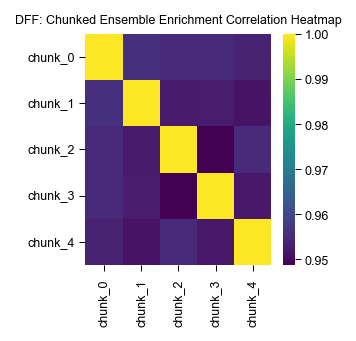

In [47]:
## pivot dff chunked ensembles activation and plot heatmap
enriched_by_chunk_dff = get_pivoted_enrichment_heatmap(all_chunked_ensembles)
fig, ax = plt.subplots(figsize=(2,2))
chunk_col = [c for c in enriched_by_chunk_dff.columns if 'chunk_' in c]
sns.heatmap(enriched_by_chunk_dff[chunk_col].corr(), vmax = 1, cmap='viridis')   
ax.set_title("DFF: Chunked Ensemble Enrichment Correlation Heatmap")


#### import raw shuffle data for DFF and spikes, to compare shuffle chunk similarity

In [48]:
spikes_shuffle_path = results_dir / Path(f"spikes_ensemble_detection_20-Nov-2025_5000 shuffles/shuffled_dfs_5000_per_subject")
print(f"Loading shuffles from {spikes_shuffle_path}")
all_shuffles_spikes =  read_shuffle_parquet_from_folder(spikes_shuffle_path) # Load all parquet files from that folder


Loading shuffles from C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\spikes_ensemble_detection_20-Nov-2025_5000 shuffles\shuffled_dfs_5000_per_subject
 Loaded: 10_3_HET_RS1
 Loaded: 10_3_HET_RS2
 Loaded: 10_3_HET_RS3
 Loaded: 13_3_HET_RS1
 Loaded: 13_3_HET_RS2
 Loaded: 13_3_HET_RS3
 Loaded: 13_4_WT_RS1
 Loaded: 13_4_WT_RS2
 Loaded: 13_5_HET_RS1
 Loaded: 13_5_HET_RS2
 Loaded: 13_5_HET_RS3
 Loaded: 13_6_WT_RS1
 Loaded: 13_6_WT_RS2
 Loaded: 13_8_HET_RS1
 Loaded: 13_8_HET_RS2
 Loaded: 13_8_HET_RS3
 Loaded: 14_2_WT_RS1
 Loaded: 14_2_WT_RS2
 Loaded: 15_1_HET_RS1
 Loaded: 15_1_HET_RS2
 Loaded: 15_1_HET_RS3
 Loaded: 5_3_WT_RS1
 Loaded: 5_3_WT_RS2
 Loaded: 6_2_WT_RS1
 Loaded: 6_2_WT_RS2
 Loaded: 7_2_WT_RS1
 Loaded: 7_4_WT_RS1
 Loaded: 7_5_WT_RS1
 Loaded: 7_5_WT_RS2
 Loaded: 7_6_HET_RS1
 Loaded: 7_6_HET_RS2
 Loaded: 7_6_HET_RS3
 Loaded: 9_3_HET_RS1
 Loaded: 9_3_HET_RS2
 Loaded: 9_3_HET_RS3
Loaded 35 subjects from previous run


In [49]:
#if you are importing something that's NOT the current data type used, make sure to re-create raster dataframes for that datatype
# Loop over imported subject rasters and create pandas DataFrames
raster_dataframes_spikes = transform_all_datasets(loaded_objects, datatype = 'raster', normalize = 'none')
all_chunk_ens_spikes = chunk_shuffles_by_subject(all_shuffles_spikes, raster_dataframes_spikes, chunk_size=1000)
enriched_by_chunk_spikes = get_pivoted_enrichment_heatmap(all_chunk_ens_spikes)
enriched_by_chunk_spikes.head()


Processing raster of 10_3_HET_RS1: 163651520 bytes
Processing raster of 10_3_HET_RS2: 131631360 bytes
Processing raster of 10_3_HET_RS3: 136645264 bytes
Processing raster of 13_3_HET_RS1: 245162240 bytes
Processing raster of 13_3_HET_RS2: 126035160 bytes
Processing raster of 13_3_HET_RS3: 150853752 bytes
Processing raster of 13_4_WT_RS1: 225208584 bytes
Processing raster of 13_4_WT_RS2: 145343160 bytes
Processing raster of 13_5_HET_RS1: 220176000 bytes
Processing raster of 13_5_HET_RS2: 141283000 bytes
Processing raster of 13_5_HET_RS3: 101650760 bytes
Processing raster of 13_6_WT_RS1: 407216056 bytes
Processing raster of 13_6_WT_RS2: 286371552 bytes
Processing raster of 13_8_HET_RS1: 205506288 bytes
Processing raster of 13_8_HET_RS2: 184071712 bytes
Processing raster of 13_8_HET_RS3: 247363296 bytes
Processing raster of 14_2_WT_RS1: 158077680 bytes
Processing raster of 14_2_WT_RS2: 170570944 bytes
Processing raster of 15_1_HET_RS1: 209435040 bytes
Processing raster of 15_1_HET_RS2: 18

,subject_name,task_stage,cell,chunk_0,chunk_1,chunk_2,chunk_3,chunk_4
0,10_3_HET_RS1,Early_IA_Correct,cell_1,False,False,False,False,False
1,10_3_HET_RS1,Early_IA_Correct,cell_10,False,False,False,False,False
2,10_3_HET_RS1,Early_IA_Correct,cell_100,False,False,False,False,False
3,10_3_HET_RS1,Early_IA_Correct,cell_101,False,False,False,False,False
4,10_3_HET_RS1,Early_IA_Correct,cell_102,False,False,False,False,False


{'10_3_HET_RS1':               cell_1  cell_2  cell_3  cell_4  cell_5  cell_6  cell_7  cell_8  \
 frame_14928      1.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
 frame_14929      1.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
 frame_14930      1.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
 frame_14931      1.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
 frame_14932      1.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
 ...              ...     ...     ...     ...     ...     ...     ...     ...   
 frame_150410     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
 frame_150411     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
 frame_150412     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
 frame_150413     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
 frame_150414     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
 
          

<Axes: >

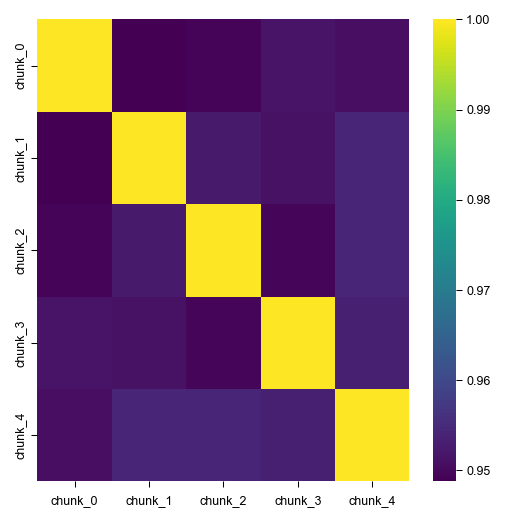

In [50]:
fig, ax = plt.subplots(figsize=(4,4))
chunk_col = [c for c in enriched_by_chunk_spikes.columns if 'chunk_' in c]
sns.heatmap(enriched_by_chunk_spikes[chunk_col].corr(), vmax = 1, cmap='viridis')   


In [51]:
def get_intercol_corrs(df: pd.DataFrame, stage_names: List[str], suffix1: str, suffix2: str) -> pd.DataFrame:
    """ Calculate correlations between columns with specified suffixes for each stage name.
    Inputs:
    df : DataFrame with columns to correlate
    stage_names : list of stage names to look for
    suffix1 : first suffix to append to stage names
    suffix2 : second suffix to append to stage names

    Returns: DataFrame of correlations"""
    
    correlations = {}
    for stage in stage_names:
        col1 = f"{stage}{suffix1}"
        col2 = f"{stage}{suffix2}"
        if col1 in df.columns and col2 in df.columns:
            corr_value = df[col1].corr(df[col2])
            correlations[stage] = corr_value
        else:
            print(f"Warning: Columns {col1} or {col2} not found in DataFrame.")
    
    corr_df = pd.DataFrame.from_dict(correlations, orient='index', columns=['Correlation'])
    return corr_df

      subject_name      task_stage     cell  chunk_0_dff  chunk_1_dff  \
32170   7_5_WT_RS1  Early_IA_Error  cell_95        False        False   

       chunk_2_dff  chunk_3_dff  chunk_4_dff  chunk_0_spikes  chunk_1_spikes  \
32170        False        False        False           False           False   

       chunk_2_spikes  chunk_3_spikes  chunk_4_spikes  
32170           False           False           False  


Text(0.5, 0.98, 'Python| Correlation between sets of 1000 shuffles each, for ensembles detected in zscored DFF & Spike rasters')

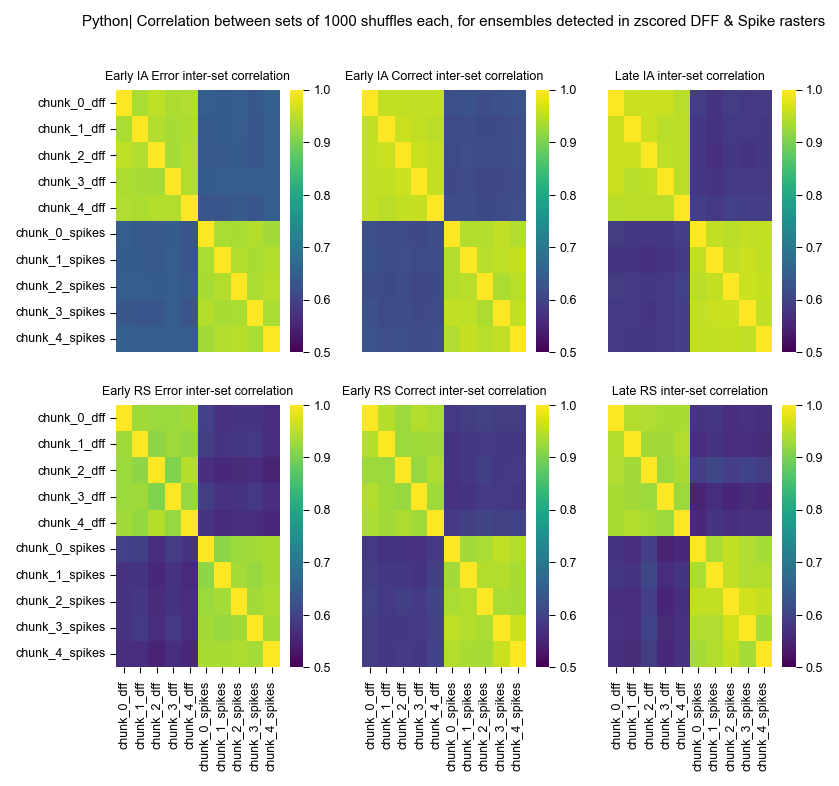

In [71]:
#merge enrich by chunk spikes and enriched by chunk dff
merged_enriched_chunks = pd.merge(enriched_by_chunk_dff, enriched_by_chunk_spikes, on=['subject_name', 'task_stage', 'cell'], suffixes=('_dff', '_spikes'))
merge_chunk_col = [c for c in merged_enriched_chunks.columns if 'chunk_' in c]
print(merged_enriched_chunks.sample())

## make figure comparing correlation
fig,axes = plt.subplots(2,3, figsize=(6,5))
for s, stage in enumerate(stage_names):
    ax = axes.flatten()[s]
    stage_mask = merged_enriched_chunks['task_stage'] == stage
    stage_vals = merged_enriched_chunks.loc[stage_mask, merge_chunk_col].corr()
    sns.heatmap(stage_vals,vmin = 0.5, cmap='viridis', ax=ax)
    #drop x and y ticks if not on edges
    if s not in [3,0]:
        ax.set_yticks([])
    if s not in [3,4,5]:
        ax.set_xticks([])
    ax.set_title(f"{stage.replace("_", " ")} inter-set correlation")
fig.suptitle("Python| Correlation between sets of 1000 shuffles each, for ensembles detected in zscored DFF & Spike rasters")

Text(0.5, 0.98, 'Python| Correlation between sets of 1000 shuffles each, for ensembles detected in zscored DFF & Spike rasters')

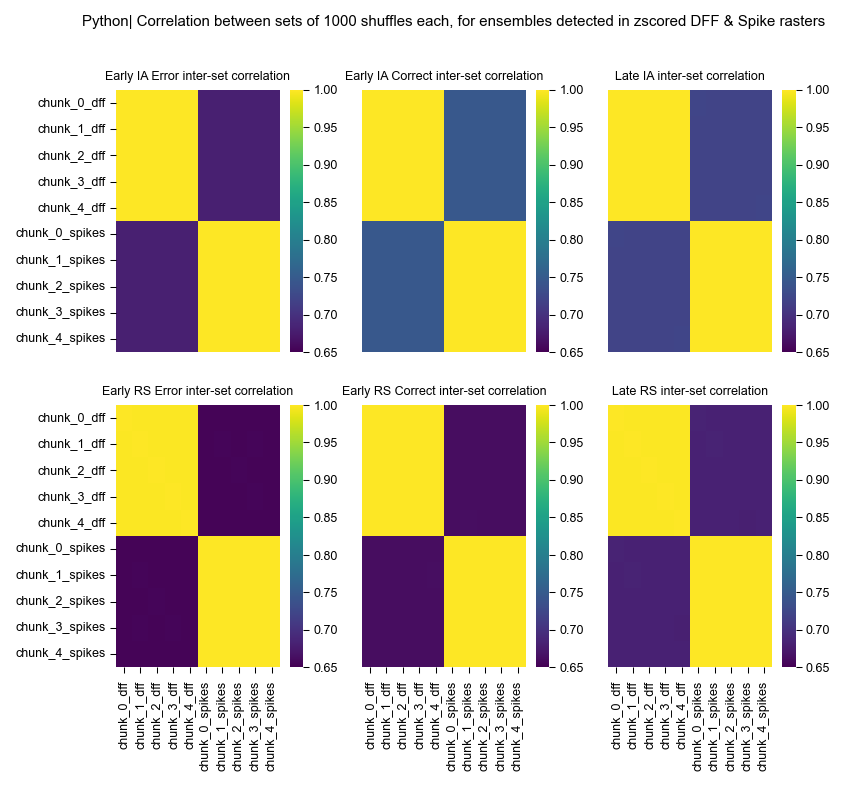

In [82]:
#use pvalue for corr 
pval_by_chunk_spikes = get_pivoted_enrichment_heatmap(all_chunk_ens_spikes, pivot_values = 'percent_shuffle >= real')
pval_by_chunk_dff = get_pivoted_enrichment_heatmap(all_chunked_ensembles, pivot_values = 'percent_shuffle >= real')
merge_pval_chunks = pd.merge(pval_by_chunk_dff, pval_by_chunk_spikes, on=['subject_name', 'task_stage', 'cell'], suffixes=('_dff', '_spikes'))
merge_chunk_col = [c for c in merged_enriched_chunks.columns if 'chunk_' in c]

fig,axes = plt.subplots(2,3, figsize=(6,5))
for s, stage in enumerate(stage_names):
    ax = axes.flatten()[s]
    stage_mask = merge_pval_chunks['task_stage'] == stage
    stage_vals = merge_pval_chunks.loc[stage_mask, merge_chunk_col].corr()

    sns.heatmap(stage_vals,cmap='viridis', vmin = 0.65, ax=ax)
    #drop x and y ticks if not on edges
    if s not in [3,0]:
        ax.set_yticks([])
    if s not in [3,4,5]:
        ax.set_xticks([])
    ax.set_title(f"{stage.replace("_", " ")} inter-set correlation")
fig.suptitle("Python| Correlation between sets of 1000 shuffles each, for ensembles detected in zscored DFF & Spike rasters")

In [83]:
merge_pval_chunks

,subject_name,task_stage,cell,chunk_0_dff,chunk_1_dff,chunk_2_dff,chunk_3_dff,chunk_4_dff,chunk_0_spikes,chunk_1_spikes,chunk_2_spikes,chunk_3_spikes,chunk_4_spikes
0,10_3_HET_RS1,Early_IA_Correct,cell_1,0.434,0.453,0.463,0.455,0.463,1.000,1.000,1.000,1.000,1.000
1,10_3_HET_RS1,Early_IA_Correct,cell_10,0.165,0.160,0.157,0.164,0.170,0.143,0.136,0.136,0.146,0.151
2,10_3_HET_RS1,Early_IA_Correct,cell_100,0.991,0.989,0.988,0.989,0.991,1.000,1.000,1.000,1.000,1.000
3,10_3_HET_RS1,Early_IA_Correct,cell_101,0.997,0.992,0.994,0.994,0.992,1.000,1.000,1.000,1.000,1.000
4,10_3_HET_RS1,Early_IA_Correct,cell_102,0.689,0.690,0.697,0.689,0.673,1.000,1.000,1.000,1.000,1.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
40635,9_3_HET_RS3,truncated_post_outcome,cell_95,0.298,0.310,0.326,0.303,0.279,0.270,0.261,0.283,0.288,0.242
40636,9_3_HET_RS3,truncated_post_outcome,cell_96,0.009,0.006,0.013,0.015,0.008,0.009,0.007,0.013,0.013,0.012
40637,9_3_HET_RS3,truncated_post_outcome,cell_97,0.297,0.323,0.329,0.302,0.299,0.289,0.321,0.313,0.299,0.275
40638,9_3_HET_RS3,truncated_post_outcome,cell_98,1.000,1.000,1.000,1.000,0.997,0.998,0.995,0.999,1.000,0.997


In [86]:
merge_pval_chunks.groupby('subject_name')['cell'].nunique().sum()

5961

In [81]:
stage_vals

,chunk_0_dff,chunk_1_dff,chunk_2_dff,chunk_3_dff,chunk_4_dff,chunk_0_spikes,chunk_1_spikes,chunk_2_spikes,chunk_3_spikes,chunk_4_spikes
chunk_0_dff,1.000000,0.998605,0.998592,0.998572,0.998543,0.683091,0.682636,0.682609,0.682410,0.682646
chunk_1_dff,0.998605,1.000000,0.998569,0.998572,0.998552,0.682775,0.682860,0.682577,0.682367,0.682607
chunk_2_dff,0.998592,0.998569,1.000000,0.998584,0.998564,0.681950,0.681787,0.682039,0.681531,0.681800
chunk_3_dff,0.998572,0.998572,0.998584,1.000000,0.998550,0.682168,0.681984,0.681935,0.682011,0.681995
chunk_4_dff,0.998543,0.998552,0.998564,0.998550,1.000000,0.681688,0.681523,0.681506,0.681298,0.681839
chunk_0_spikes,0.683091,0.682775,0.681950,0.682168,0.681688,1.000000,0.999536,0.999513,0.999559,0.999503
chunk_1_spikes,0.682636,0.682860,0.681787,0.681984,0.681523,0.999536,1.000000,0.999544,0.999554,0.999530
chunk_2_spikes,0.682609,0.682577,0.682039,0.681935,0.681506,0.999513,0.999544,1.000000,0.999501,0.999527
chunk_3_spikes,0.682410,0.682367,0.681531,0.682011,0.681298,0.999559,0.999554,0.999501,1.000000,0.999528
chunk_4_spikes,0.682646,0.682607,0.681800,0.681995,0.681839,0.999503,0.999530,0.999527,0.999528,1.000000


In [53]:
# This is odd though- why would spikes and dff ensembles be so correlated on the identity? 

#### import both DFF & spike ensemble parquets


In [54]:
results_dir

WindowsPath('C:/Users/13car/Dropbox/local_github_repos_personal/dlx56_mPFC_1p_SohalLab/results')

In [55]:
# import DFF ensemble matrix 
dff_ens_path = results_dir / Path(r"dff_ensemble_detection_21-Nov-2025_5000 shuffles\dff_postoutcome_python_ensembles_5000_shuff_21-Nov-2025_.parquet")
dff_ens = pd.read_parquet(dff_ens_path)
if 'data_type' not in dff_ens.columns:
    dff_ens['data_type'] = 'dff'
print(dff_ens.info())
#get ensemble info from canon df
dff_ens.tail(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40640 entries, 0 to 40639
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   task_stage               40640 non-null  object 
 1   cell                     40640 non-null  object 
 2   percentile_95            40640 non-null  float64
 3   mean                     40640 non-null  float32
 4   enriched                 40640 non-null  bool   
 5   percent_shuffle >= real  40640 non-null  float64
 6   subject_name             40640 non-null  object 
 7   neuron_id                40640 non-null  object 
 8   date_made                40640 non-null  object 
 9   n_shuffles               40640 non-null  int64  
 10  data_type                40640 non-null  object 
dtypes: bool(1), float32(1), float64(2), int64(1), object(6)
memory usage: 3.0+ MB
None


,task_stage,cell,percentile_95,mean,enriched,percent_shuffle >= real,subject_name,neuron_id,date_made,n_shuffles,data_type
40637,Late_IA,cell_215,0.001142,0.000316,False,0.9184,9_3_HET_RS3,9_3_HET_RS3-215,21-Nov-2025,5000,dff
40638,Late_RS,cell_215,0.001239,0.001194,False,0.0616,9_3_HET_RS3,9_3_HET_RS3-215,21-Nov-2025,5000,dff
40639,truncated_post_outcome,cell_215,0.000627,0.000333,False,0.9992,9_3_HET_RS3,9_3_HET_RS3-215,21-Nov-2025,5000,dff


In [56]:
data_types

['spikes', 'dff']

In [57]:
#import last spikes ensemble matrix for comparison
spikes_ens_path = results_dir / Path(r"spikes_ensemble_detection_20-Nov-2025_5000 shuffles\spikes_postoutcome_python_ensembles_5000_shuff_20-Nov-2025_.parquet")
spikes_ens = pd.read_parquet(spikes_ens_path)
if 'data_type' not in spikes_ens.columns:
    spikes_ens['data_type'] = 'spikes'
print(spikes_ens.info())
spikes_ens.tail(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40640 entries, 0 to 40639
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   task_stage               40640 non-null  object 
 1   cell                     40640 non-null  object 
 2   percentile_95            40640 non-null  float64
 3   mean                     40640 non-null  float64
 4   enriched                 40640 non-null  bool   
 5   percent_shuffle >= real  40640 non-null  float64
 6   subject_name             40640 non-null  object 
 7   neuron_id                40640 non-null  object 
 8   date_made                40640 non-null  object 
 9   n_shuffles               40640 non-null  int64  
 10  data_type                40640 non-null  object 
dtypes: bool(1), float64(3), int64(1), object(6)
memory usage: 3.1+ MB
None


,task_stage,cell,percentile_95,mean,enriched,percent_shuffle >= real,subject_name,neuron_id,date_made,n_shuffles,data_type
40637,Late_IA,cell_215,0.022033,0.000000,False,1.0000,9_3_HET_RS3,9_3_HET_RS3-215,20-Nov-2025,5000,spikes
40638,Late_RS,cell_215,0.025000,0.017500,False,0.1106,9_3_HET_RS3,9_3_HET_RS3-215,20-Nov-2025,5000,spikes
40639,truncated_post_outcome,cell_215,0.007345,0.000332,False,0.9992,9_3_HET_RS3,9_3_HET_RS3-215,20-Nov-2025,5000,spikes


In [111]:
## pivot both enrichment vectors, then merge
spikes_ens_matrix = spikes_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'enriched', fill_value = None).astype(float)
dff_ens_matrix = dff_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'enriched', fill_value = None).astype(float)
compare_spike_dff_ens = spikes_ens_matrix.merge(dff_ens_matrix, on = 'neuron_id', suffixes=('_spikes', '_dff'))
print(compare_spike_dff_ens.info())
compare_spike_dff_ens.head(3)

<class 'pandas.core.frame.DataFrame'>
Index: 5961 entries, 10_3_HET_RS1-1 to 9_3_HET_RS3-99
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Early_IA_Correct_spikes        5961 non-null   float64
 1   Early_IA_Error_spikes          4874 non-null   float64
 2   Early_RS_Correct_spikes        5961 non-null   float64
 3   Early_RS_Error_spikes          5961 non-null   float64
 4   Late_IA_spikes                 5961 non-null   float64
 5   Late_RS_spikes                 5961 non-null   float64
 6   truncated_post_outcome_spikes  5961 non-null   float64
 7   Early_IA_Correct_dff           5961 non-null   float64
 8   Early_IA_Error_dff             4874 non-null   float64
 9   Early_RS_Correct_dff           5961 non-null   float64
 10  Early_RS_Error_dff             5961 non-null   float64
 11  Late_IA_dff                    5961 non-null   float64
 12  Late_RS_dff                   

task_stage,Early_IA_Correct_spikes,Early_IA_Error_spikes,Early_RS_Correct_spikes,Early_RS_Error_spikes,Late_IA_spikes,Late_RS_spikes,truncated_post_outcome_spikes,Early_IA_Correct_dff,Early_IA_Error_dff,Early_RS_Correct_dff,Early_RS_Error_dff,Late_IA_dff,Late_RS_dff,truncated_post_outcome_dff
neuron_id,,,,,,,,,,,,,,
10_3_HET_RS1-1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
10_3_HET_RS1-10,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
10_3_HET_RS1-100,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [112]:
df = compare_spike_dff_ens
correlations = {stage: df[stage+"_spikes"].corr(df[stage + '_dff']) for stage in stage_names}
corr_df = pd.DataFrame.from_dict(correlations, orient='index', columns=['Correlation'])
print(f" Correlation of enrichment vectors for DFF data vs SPIKE data: \n{corr_df}")

 Correlation of enrichment vectors for DFF data vs SPIKE data: 
                  Correlation
Early_IA_Error       0.643866
Early_IA_Correct     0.617139
Late_IA              0.579809
Early_RS_Error       0.575530
Early_RS_Correct     0.587447
Late_RS              0.578939


In [113]:
## pivot both p-value matrices, then merge
spikes_ens_pval = spikes_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'percent_shuffle >= real', fill_value = False).astype(float)
dff_ens_pval = dff_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'percent_shuffle >= real', fill_value = False).astype(float)
compare_spike_dff_p = spikes_ens_pval.merge(dff_ens_pval, on = 'neuron_id', suffixes=('_spikes', '_dff'))
print(compare_spike_dff_p.info())
compare_spike_dff_p.head(3)

<class 'pandas.core.frame.DataFrame'>
Index: 5961 entries, 10_3_HET_RS1-1 to 9_3_HET_RS3-99
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Early_IA_Correct_spikes        5961 non-null   float64
 1   Early_IA_Error_spikes          5961 non-null   float64
 2   Early_RS_Correct_spikes        5961 non-null   float64
 3   Early_RS_Error_spikes          5961 non-null   float64
 4   Late_IA_spikes                 5961 non-null   float64
 5   Late_RS_spikes                 5961 non-null   float64
 6   truncated_post_outcome_spikes  5961 non-null   float64
 7   Early_IA_Correct_dff           5961 non-null   float64
 8   Early_IA_Error_dff             5961 non-null   float64
 9   Early_RS_Correct_dff           5961 non-null   float64
 10  Early_RS_Error_dff             5961 non-null   float64
 11  Late_IA_dff                    5961 non-null   float64
 12  Late_RS_dff                   

task_stage,Early_IA_Correct_spikes,Early_IA_Error_spikes,Early_RS_Correct_spikes,Early_RS_Error_spikes,Late_IA_spikes,Late_RS_spikes,truncated_post_outcome_spikes,Early_IA_Correct_dff,Early_IA_Error_dff,Early_RS_Correct_dff,Early_RS_Error_dff,Late_IA_dff,Late_RS_dff,truncated_post_outcome_dff
neuron_id,,,,,,,,,,,,,,
10_3_HET_RS1-1,1.0000,0.0008,1.0,1.0000,1.0000,1.0,0.1388,0.4536,0.0040,0.2276,0.6784,0.4888,0.7558,0.0696
10_3_HET_RS1-10,0.1424,0.0046,1.0,0.0972,0.2986,1.0,0.0002,0.1632,0.0152,0.8634,0.0508,0.3794,0.9782,0.0008
10_3_HET_RS1-100,1.0000,1.0000,1.0,1.0000,1.0000,1.0,0.9936,0.9896,0.8938,0.9890,0.8388,0.9968,0.9750,0.9978


In [114]:
corr_df = get_intercol_corrs(compare_spike_dff_p, stage_names, suffix1="_spikes", suffix2="_dff")
print(f" Correlation of enrichment vectors for DFF data vs SPIKE data: \n{corr_df}")

 Correlation of enrichment vectors for DFF data vs SPIKE data: 
                  Correlation
Early_IA_Error       0.779182
Early_IA_Correct     0.745727
Late_IA              0.721740
Early_RS_Error       0.654836
Early_RS_Correct     0.662784
Late_RS              0.682847


#### Threshold time-series df to remove 0 

In [ ]:
#concatenate all raster dfs  into 1 DF

raw_tseries_df = pd.concat(raster_dataframes.values(), axis = 0).reset_index(drop = True)
raw_tseries_df

,cell_1,cell_2,cell_3,cell_4,cell_5,cell_6,cell_7,cell_8,cell_9,cell_10,...,cell_238,cell_239,cell_240,cell_241,cell_242,cell_243,cell_244,cell_245,cell_246,cell_247
0,10.162713,-0.265766,-0.284692,0.528677,-0.262349,-0.417058,-0.284174,2.295044,-0.166770,-0.280019,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10.271276,-0.265766,-0.284692,0.556811,-0.262349,-0.417058,-0.284174,2.436276,-0.037289,-0.280019,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10.573703,-0.265766,-0.284692,0.611299,-0.262349,-0.417058,-0.284174,2.459066,0.010341,-0.280019,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10.976413,-0.265766,-0.284692,0.649525,-0.262349,-0.417058,-0.284174,2.421428,-0.002545,-0.280019,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10.966867,-0.265766,-0.284692,0.359131,-0.262349,-0.417058,-0.284174,2.579288,0.270379,-0.280019,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4388193,-0.566054,-0.144826,-0.217396,-0.223254,-0.676856,-0.364531,-0.371669,-0.430415,-0.189752,-0.294282,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4388194,-0.573453,-0.144826,-0.225749,-0.251636,-0.667727,-0.388656,-0.351714,-0.430415,-0.158734,-0.255533,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4388195,-0.577801,-0.144826,-0.238627,-0.235148,-0.651112,-0.425844,-0.278091,-0.430415,-0.189752,-0.234387,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4388196,-0.579331,-0.144826,-0.238627,-0.225784,-0.642141,-0.425844,-0.251673,-0.430415,-0.237565,-0.207176,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [177]:
test_df = raster_dataframes['13_3_HET_RS1']
test_df

,cell_1,cell_2,cell_3,cell_4,cell_5,cell_6,cell_7,cell_8,cell_9,cell_10,...,labels,normalized,datatype,subject_name,geno,session,trial_num,task_stage,trial_section,truncated_post
frame_16664,-0.345449,1.560174,1.651437,-0.32494,-0.501648,1.766378,-0.231444,5.211718,-0.281965,-0.301712,...,2,baseline_zscore,dff,13_3_HET_RS1,HET,RS1,1,Early_IA_Correct,pre_outcome,True
frame_16665,-0.345449,1.576821,3.067161,-0.32494,-0.501648,1.758024,-0.158237,4.957682,-0.349788,-0.301712,...,2,baseline_zscore,dff,13_3_HET_RS1,HET,RS1,1,Early_IA_Correct,pre_outcome,True
frame_16666,-0.345449,1.625795,3.010599,-0.32494,-0.501648,1.800166,-0.191557,4.823406,-0.233398,-0.301712,...,2,baseline_zscore,dff,13_3_HET_RS1,HET,RS1,1,Early_IA_Correct,pre_outcome,True
frame_16667,-0.345449,1.603045,2.312696,-0.32494,-0.501648,1.813692,-0.270018,4.724502,-0.156136,-0.301712,...,2,baseline_zscore,dff,13_3_HET_RS1,HET,RS1,1,Early_IA_Correct,pre_outcome,True
frame_16668,-0.345449,1.524034,2.409276,-0.32494,-0.501648,1.786094,-0.306547,4.726196,-0.234185,-0.301712,...,2,baseline_zscore,dff,13_3_HET_RS1,HET,RS1,1,Early_IA_Correct,pre_outcome,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
frame_191528,0.649147,-0.447289,-0.416859,-0.32494,-0.498791,-0.627763,-0.384820,-0.087464,-0.354613,-0.301712,...,15,baseline_zscore,dff,13_3_HET_RS1,HET,RS1,46,Late_RS,ITI,True
frame_191529,0.889961,-0.447289,-0.416859,-0.32494,-0.501648,-0.583336,-0.384820,-0.026779,-0.353765,-0.301712,...,15,baseline_zscore,dff,13_3_HET_RS1,HET,RS1,46,Late_RS,ITI,True
frame_191530,0.995933,-0.447289,-0.416859,-0.32494,-0.501648,-0.603038,-0.351585,-0.054568,-0.354613,-0.301712,...,15,baseline_zscore,dff,13_3_HET_RS1,HET,RS1,46,Late_RS,ITI,True
frame_191531,1.051722,-0.447289,-0.416859,-0.32494,-0.498526,-0.662431,-0.330024,-0.071195,-0.355920,-0.301712,...,15,baseline_zscore,dff,13_3_HET_RS1,HET,RS1,46,Late_RS,ITI,True


In [185]:
def extract_trial_windows(df):
    """Extract last 3s pre-outcome and first 15s post-outcome for each trial."""
    
    # Validation: Check monotonicity within each trial
    grouped = df.groupby(['subject_name', 'session', 'trial_num'])
    
    for trial_id, trial_data in grouped:
        # Extract frame numbers from index (e.g., "frame_16664" -> 16664)
        frame_nums = trial_data.index.str.extract(r'frame_(\d+)')[0].astype(int)
        
        if not frame_nums.is_monotonic_increasing:
            raise ValueError(f"Non-monotonic indices in trial {trial_id}")
    
    # Extract windows
    trial_windows = []
    
    for trial_id, trial_data in grouped:
        pre = trial_data[trial_data['trial_section'] == 'pre_outcome'].tail(60)
        post = trial_data[trial_data['trial_section'] == 'post_outcome'].head(300)
         # Combine pre and post for this trial
        combined = pd.concat([pre, post])
         
        # Add frame index starting at 1 for this trial's window
        combined['trial_window_frame'] = range(1, len(combined) + 1)
        trial_windows.append(combined)

    # Return all trials combined
    return pd.concat(trial_windows)

In [186]:
extract_trial_windows(test_df)

,cell_1,cell_2,cell_3,cell_4,cell_5,cell_6,cell_7,cell_8,cell_9,cell_10,...,normalized,datatype,subject_name,geno,session,trial_num,task_stage,trial_section,truncated_post,trial_window_frame
frame_17044,35.988403,-0.447289,0.951332,0.947136,-0.501648,-0.784555,-0.384820,-0.098977,-0.355920,-0.189560,...,baseline_zscore,dff,13_3_HET_RS1,HET,RS1,1,Early_IA_Correct,pre_outcome,True,1
frame_17045,35.320080,-0.447289,0.528692,1.245236,-0.501648,-0.784555,-0.384820,-0.179425,-0.355920,-0.081524,...,baseline_zscore,dff,13_3_HET_RS1,HET,RS1,1,Early_IA_Correct,pre_outcome,True,2
frame_17046,34.493092,-0.447289,0.034690,1.022600,-0.501648,-0.784555,-0.384820,-0.204580,-0.355920,0.007232,...,baseline_zscore,dff,13_3_HET_RS1,HET,RS1,1,Early_IA_Correct,pre_outcome,True,3
frame_17047,34.316143,-0.447289,0.212265,0.632367,-0.501648,-0.784555,-0.384820,-0.243357,-0.355920,0.040128,...,baseline_zscore,dff,13_3_HET_RS1,HET,RS1,1,Early_IA_Correct,pre_outcome,True,4
frame_17048,35.764805,-0.447289,0.455773,0.614135,-0.501648,-0.784555,-0.384820,-0.243357,-0.355920,-0.045424,...,baseline_zscore,dff,13_3_HET_RS1,HET,RS1,1,Early_IA_Correct,pre_outcome,True,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
frame_186119,0.265336,-0.405733,-0.416859,-0.103519,-0.501648,-0.766222,-0.384820,-0.221434,-0.355920,-0.131037,...,baseline_zscore,dff,13_3_HET_RS1,HET,RS1,46,Late_RS,post_outcome,True,356
frame_186120,0.207647,-0.396320,-0.416859,-0.143262,-0.501648,-0.747714,-0.384820,-0.133124,-0.295137,0.099858,...,baseline_zscore,dff,13_3_HET_RS1,HET,RS1,46,Late_RS,post_outcome,True,357
frame_186121,-0.044333,-0.327777,-0.416859,-0.073460,-0.501648,-0.726260,-0.384820,-0.058695,-0.255705,0.138173,...,baseline_zscore,dff,13_3_HET_RS1,HET,RS1,46,Late_RS,post_outcome,True,358
frame_186122,-0.162813,-0.326120,-0.416859,0.007355,-0.501648,-0.750061,-0.384820,-0.081788,-0.294700,-0.022017,...,baseline_zscore,dff,13_3_HET_RS1,HET,RS1,46,Late_RS,post_outcome,True,359


In [ ]:
#for each trial, extract pre and post-outcome activity time-series
#use pre-established hyperparameters: 
hyper_param_dict['window_to_bin'] = 5 #n frames to average over
hyper_param_dict['bin_size'] = hyper_param_dict['window_to_bin']/20 #in seconds, resulting binsize
hyper_param_dict['n_sec_to_rotate'] = 0
hyper_param_dict['n_pre_bin_to_drop'] = 2*4 #how many bins (seconds * window size0  of the pre-decision to drop
hyper_param_dict['n_post_end_bin_to_drop'] = 0*4 #how many bins (seconds * window size0  of END the post-decision to drop)



TypeError: get_mean_postoutcome_stage_activity() got an unexpected keyword argument 'fps'

In [ ]:
from preprocess_data import hyper_param_dict, bin_rotate_timeseries, get_numeric_cols_timeseries, preprocess_post_df, get_post_enrichment, remove_low_activity_WT_datasets, drop_end_bins_of_trials, drop_start_bins_of_trials

## run main body of analysis 
cols_to_drop = ['threshold_with_shuffle','peak_dff_threshold_percentile','drop_low_value_peak_events','cutoff_filter','peak_event_cutoff_percentile']

outcome_post =outcome_post.drop([x for x in cols_to_drop if x in outcome_post], axis = 1).dropna(subset = ['task_phase_vec'])
cmi.hf.annotate_csv(outcome_post, 'name')
## begin preprocess- bin and rotate timeseries 
outcome_post = bin_rotate_timeseries(outcome_post, window_size = window_to_bin, rotate_by = n_sec_to_rotate)
#get stage info
numeric_col = get_numeric_cols_timeseries(outcome_post, " to ")
## get post enrichment generic func
trial_tseries_df_raw = remove_low_activity_WT_datasets(preprocess_post_df(outcome_post, get_post_enrichment(cell_period_active)), numeric_col, drop_low_responders) ## logic- drop lowest 2 active datasets
normed_trial_tseries_df = cmi.hf.run_min_max_norm_on_timeseries(norm_data, trial_tseries_df_raw, ['name', 'unique_ID'], numeric_col, 'max_trial_val') #min_max_norm = True
normed_trial_tseries_df.to_csv(save_name)
#get mean of each trial
normed_trial_tseries_df['mean_rate'] =normed_trial_tseries_df[[c for c in numeric_col if '-' not in c]].mean(axis = 1) #mean rate is post outcome only
normed_trial_tseries_df['active_in_trial'] =normed_trial_tseries_df['mean_rate']>0
#OPTIONAL- drop N bins from start and M bins from end of time-series
normed_trial_tseries_df = drop_end_bins_of_trials(normed_trial_tseries_df,numeric_col,  n_end_timebins_to_drop = hyper_param_dict['n_post_end_bin_to_drop'] )
normed_trial_tseries_df = drop_start_bins_of_trials(normed_trial_tseries_df,numeric_col,  n_start_timebins_to_drop =hyper_param_dict['n_pre_bin_to_drop'])


In [171]:
numeric_col = cmi.pp.get_numeric_cols_timeseries(trial_tseries_df_norm, " to ")
unit_mean_tseries =  cmi.pp.get_unit_mean_timeseries_by_phase(trial_tseries_df_norm,['trial_num'], ['name', 'neuron_ID','geno_day', stage_col], numeric_col) 
subject_stage_info_df = cmi.pp.get_subject_stage_info_df(trial_tseries_df_norm) # get subj level dfs
n_total_units = unit_mean_tseries.groupby(by = 'geno_day')['unique_ID'].nunique()

NameError: name 'cmi' is not defined

#### new- UMAP on enrichment matrices

In [89]:
!pip install umap-learn

   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   ---------------------------------------- 8.7/8.7 MB 60.1 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.5.2
    Uninstalling scikit-learn-1.5.2:
      Successfully uninstalled scikit-learn-1.5.2


In [150]:
# UMAP analysis on ensemble matrices
import umap
from sns_plotting_config import * #import dicts containing default plot params

# Determine first active stage for each neuron
def get_first_active_stage(row, stage_order,  non_enriched_label = 'Never'):
    """Find the first stage where neuron is enriched (value = 1)"""
    for stage in stage_order:
        if stage in row.index and row[stage] == 1:
            return stage
    return non_enriched_label

def run_umap_with_stage_labels(ensemble_matrix, stage_names, enrichment_col = None,
                                n_neighbors=15, min_dist=0.1,  
                                metric='hamming', random_state=42):
    """
    Run UMAP on ensemble matrix and label neurons by first active stage.
    
    Parameters:
    -----------
    ensemble_matrix : pd.DataFrame
        Binary ensemble membership matrix (neurons x task_stages)
    stage_names : list
        Chronological order of task stages
    n_neighbors : int
        UMAP n_neighbors parameter (default: 15)
    min_dist : float
        UMAP min_dist parameter (default: 0.1)
    metric : str
        Distance metric for UMAP (default: 'hamming')
    random_state : int
        Random seed for reproducibility (default: 42)
    
    Returns:
    --------
    results_df : pd.DataFrame
        DataFrame with columns: UMAP1, UMAP2, First_Active_Stage
    umap_model : umap.UMAP
        Fitted UMAP model (useful for transforming new data)
    """
    import umap
    import pandas as pd
    
    # Get complete data (drop rows with any NaN)
    complete_data = ensemble_matrix.dropna()
    
    print(f"Base shape: {ensemble_matrix.shape}")
    print(f"Complete cases: {complete_data.shape}")
    
    # Run UMAP
    umap_model = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric=metric,
        random_state=random_state)
    embedding = umap_model.fit_transform(complete_data)
    
    # Prepare results dataframe
    results_df = pd.DataFrame({
        'UMAP1': embedding[:, 0], 'UMAP2': embedding[:, 1],
        })
    
    # Preserve neuron IDs from index
    results_df.index = complete_data.index
    return results_df, umap_model


neuron_id
10_3_HET_RS1-1      Early_IA_Error
10_3_HET_RS1-10     Early_IA_Error
10_3_HET_RS1-100             Never
10_3_HET_RS1-101             Never
10_3_HET_RS1-102             Never
                         ...      
9_3_HET_RS3-95               Never
9_3_HET_RS3-96               Never
9_3_HET_RS3-97      Early_IA_Error
9_3_HET_RS3-98               Never
9_3_HET_RS3-99               Never
Length: 5961, dtype: object

In [166]:
#set umap params
value_to_project = 'mean'
metric = 'cosine'

# Run UMAP on both spike and DFF ensemble matrices
spike_umap_input = spikes_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = value_to_project, fill_value = False).drop(columns = 'truncated_post_outcome').astype(float)
spikes_df, umap_spikes_model = run_umap_with_stage_labels( spike_umap_input, 
    stage_names, n_neighbors=15, min_dist=0.2, metric=metric,random_state=42)

dff_umap_input = dff_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = value_to_project, fill_value = False).drop(columns = 'truncated_post_outcome').astype(float)
dff_df, umap_dff_model = run_umap_with_stage_labels(dff_umap_input,
      stage_names, n_neighbors=15, min_dist=0.2, metric=metric, random_state=42)

#join umap dfs with ensemble enrichment info
spike_cell_enrich = spikes_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'enriched', fill_value = False).astype(float).apply(get_first_active_stage, axis=1, stage_order=stage_names)
spikes_df = spikes_df.merge(spike_cell_enrich.rename('first_active_stage'), left_index=True, right_index=True)
dff_cell_enrich = dff_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'enriched', fill_value = False).astype(float).apply(get_first_active_stage, axis=1, stage_order=stage_names)
dff_df = dff_df.merge(dff_cell_enrich.rename('first_active_stage'), left_index=True, right_index=True)
# spikes_df = spikes_df.merge(spikes_ens[['neuron_id', 'task_stage', 'enriched']], left_index=True, right_on='neuron_id')
# dff_df = dff_df.merge(dff_ens[['neuron_id', 'enriched']], left_index=True, right_on='neuron_id')

Base shape: (5961, 6)
Complete cases: (5961, 6)


c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Base shape: (5961, 6)
Complete cases: (5961, 6)


c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
spikes_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = value_to_project, fill_value = False)

In [167]:
dff_df

,UMAP1,UMAP2,first_active_stage
neuron_id,,,
10_3_HET_RS1-1,12.622513,10.524050,Early_IA_Error
10_3_HET_RS1-10,11.150599,7.630769,Early_IA_Error
10_3_HET_RS1-100,5.013901,-0.784930,Never
10_3_HET_RS1-101,1.982271,1.774831,Never
10_3_HET_RS1-102,5.859055,0.542735,Never
...,...,...,...
9_3_HET_RS3-95,7.824842,6.792192,Never
9_3_HET_RS3-96,9.832567,4.483198,Never
9_3_HET_RS3-97,10.235147,10.320923,Early_IA_Error


c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use 

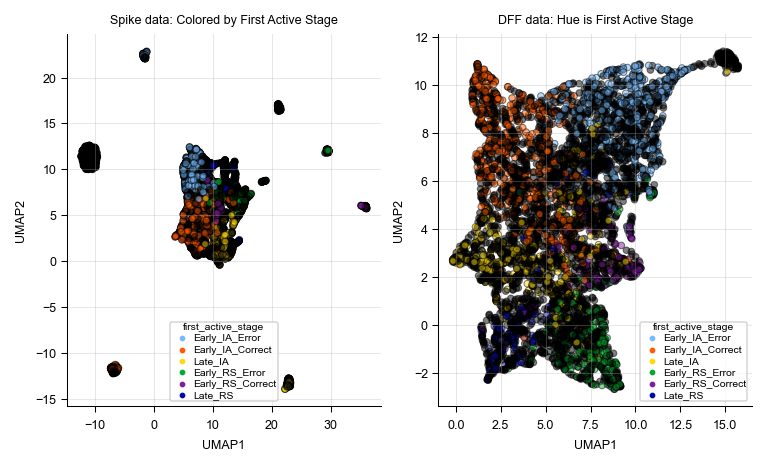

In [170]:
## PLOTTING- note that paper tSNE is projection of mean activity in stage, colored by ensemble identity
fig, axes = plt.subplots(1, 2, figsize=(5, 3), layout='constrained')
palette = [stage_palette_dict[x] for x in stage_names] + ['lightgray']
hue_col = 'first_active_stage'

# Spikes
sns.scatterplot(ax=axes[0], data=spikes_df, x='UMAP1', y='UMAP2', hue=hue_col,     palette=palette, hue_order=stage_names , s=10, alpha=0.5, edgecolor='k',linewidth=0.5, legend='full')
axes[0].set_title(f'Spike data: Colored by First Active Stage')
axes[0].grid(True, alpha=0.3)

# DFF
sns.scatterplot(ax=axes[1], data=dff_df, x='UMAP1', y='UMAP2', hue=hue_col, palette=palette, hue_order=stage_names , s=10, alpha=0.5, edgecolor='k',  linewidth=0.5, legend='full')
axes[1].set_title(f'DFF data: Hue is First Active Stage')
axes[1].grid(True, alpha=0.3)